# Results analysis — query and compare stored simulation runs
Query the SQLite results database to compare OFBQI and SBQI across multiple runs.

In [11]:
import sys
try:
    import qcn
except ImportError:
    import subprocess
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet',
        'git+https://github.com/raulpg14/Quantum-Internet-Network-Simulator.git'
    ])
    import qcn

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from qcn.engine.results_store import get_runs, get_metrics, export_csv
from qcn.engine.config import STYLE_MAP, NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [13]:
# --- All stored runs ---
runs = get_runs()
df_runs = pd.DataFrame(runs)
print(f"Total runs in database: {len(df_runs)}")
df_runs

Total runs in database: 5


,id,timestamp,network_type,sim_mode,nodes,radius,density,mc_reps,seed,duration_s
0,5,2026-06-23T08:59:29.747142,SBQI,distribution,1000,1261.0,0.00020,1,42,0.000000
1,4,2026-06-23T08:59:29.736824,OFBQI,distribution,1000,1261.0,0.00020,1,42,0.000000
2,3,2026-06-23T08:59:26.178556,SBQI,distribution,1000,1261.0,0.00020,1,42,0.000000
3,2,2026-06-23T08:59:26.165030,OFBQI,distribution,1000,1261.0,0.00020,1,42,0.000000
4,1,2026-06-23T08:46:59.192315,OFBQI,distribution,200,1261.0,0.00004,1,42,0.015815


Distribution runs: 5
Panel (a): no runs for SBQI at ρ=0.005, using all runs
Panel (a): no runs for OFBQI at ρ=0.005, using all runs
Panel (c): no runs for OFBQI at N=1000, ρ=0.0002
Panel (c): no runs for SBQI at N=1000, ρ=0.0002


C:\Users\ragap\AppData\Local\Temp\ipykernel_25256\3088392236.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.6, edgecolor='0.8')


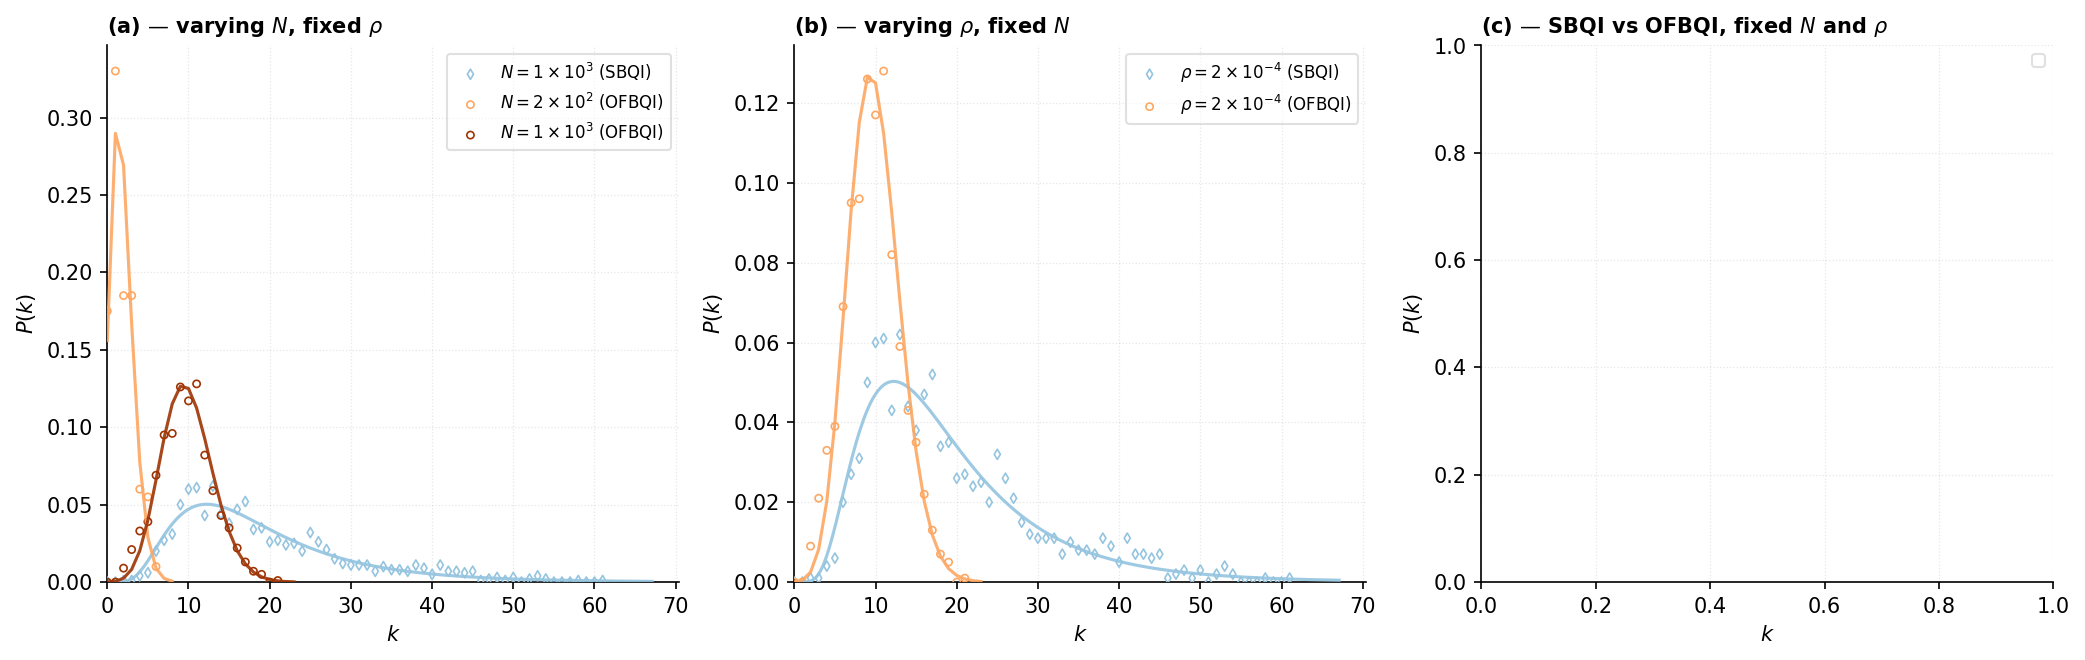

In [ ]:
# --- Compare degree distributions across runs ---
from scipy.optimize import curve_fit
from scipy.stats import poisson, lognorm, sem
from scipy.ndimage import gaussian_filter1d
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

def fit_poisson(k, lamb):
    return poisson.pmf(k, lamb)

def fit_lognormal(x, s, scale):
    return lognorm.pdf(x, s, 0, scale)

def sci_label(name, val):
    exp = int(np.floor(np.log10(val)))
    return f'${name} = {val / 10**exp:.0f} \\times 10^{{{exp}}}$'

# ── Parameters — change these to match your runs ──────────────────────────
FIXED_RHO   = 5e-3   # panel (a): fixed density, vary N
FIXED_N     = 1000   # panel (b): fixed N, vary rho
FIXED_RHO_C = 2e-4   # panel (c): fixed density for comparison
# ──────────────────────────────────────────────────────────────────────────

dist_runs = df_runs[df_runs['sim_mode'] == 'distribution'].copy()
dist_runs['density'] = dist_runs['density'].astype(float).round(10)
print(f"Distribution runs: {len(dist_runs)}")

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         10,
    'axes.linewidth':    0.8,
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ── Colormap per network type ──────────────────────────────────────────────
CMAPS = {
    NETWORK_TYPE_OFBQI: cm.Oranges,
    NETWORK_TYPE_SBQI:  cm.Blues,
}
MARKERS = {
    NETWORK_TYPE_OFBQI: STYLE_MAP[NETWORK_TYPE_OFBQI]['marker'],
    NETWORK_TYPE_SBQI:  STYLE_MAP[NETWORK_TYPE_SBQI]['marker'],
}

def get_mean_and_ci(runs_list, k_grid):
    """Given a list of (xs, ys) for a parameter group, return mean and ci on k_grid."""
    n = len(runs_list)
    matrix = np.full((n, len(k_grid)), np.nan)
    for i, (xs, ys) in enumerate(runs_list):
        idx = np.searchsorted(k_grid, xs)
        valid_mask = idx < len(k_grid)
        matrix[i, idx[valid_mask]] = ys[valid_mask]
    mean_y = np.nanmean(matrix, axis=0)
    ci = 1.96 * sem(matrix, axis=0, nan_policy='omit') if n > 1 else np.zeros_like(mean_y)
    return mean_y, ci

def plot_scatter_and_fit(ax, k_grid, mean_y, ci, color, marker, label, net_type):
    """Plot scatter markers, optional CI ribbon, and smooth fit line."""
    if np.any(ci > 0):
        ax.fill_between(k_grid,
                        np.maximum(mean_y - ci, 0),
                        mean_y + ci,
                        color=color, alpha=0.15, zorder=2)
    ax.scatter(k_grid, mean_y,
               marker=marker, s=12,
               facecolors='none', edgecolors=color,
               linewidths=0.8, label=label, zorder=3)
    valid     = mean_y > 0
    xf, yf    = k_grid[valid], mean_y[valid]
    yf_smooth = gaussian_filter1d(yf, sigma=1.5)
    if len(xf) > 2:
        try:
            if net_type == NETWORK_TYPE_OFBQI:
                mean_k  = np.average(xf, weights=yf_smooth)
                popt, _ = curve_fit(fit_poisson, xf, yf_smooth, p0=[mean_k])
                x_fit   = np.arange(0, int(xf.max()) + 3)
                y_fit   = fit_poisson(x_fit, *popt)
            else:
                popt, _ = curve_fit(fit_lognormal, xf, yf_smooth,
                                    p0=[0.5, np.mean(xf)], maxfev=5000)
                x_fit   = np.linspace(1, xf.max() * 1.1, 300)
                y_fit   = fit_lognormal(x_fit, *popt)
            ax.plot(x_fit, y_fit, color=color, lw=1.5,
                    linestyle='-', alpha=0.9, zorder=4)
        except Exception as e:
            print(f"Fit warning ({label}): {e}")

def collect_runs_by_nodes(df, net_type, fixed_rho):
    """Collect (xs, ys) grouped by nodes for a fixed density."""
    subset = df[
        (df['network_type'] == net_type) &
        (df['density'].round(10) == round(fixed_rho, 10))
    ]
    groups = {}
    for _, run in subset.iterrows():
        metrics = get_metrics(run['id'], metric='degree_prob')
        if not metrics:
            continue
        xs = np.array([m['step_n'] for m in metrics])
        ys = np.array([m['value']  for m in metrics])
        groups.setdefault(run['nodes'], []).append((xs, ys))
    return groups

def collect_runs_by_density(df, net_type, fixed_n):
    """Collect (xs, ys) grouped by density for a fixed N."""
    subset = df[
        (df['network_type'] == net_type) &
        (df['nodes'] == fixed_n)
    ]
    groups = {}
    for _, run in subset.iterrows():
        metrics = get_metrics(run['id'], metric='degree_prob')
        if not metrics:
            continue
        xs = np.array([m['step_n'] for m in metrics])
        ys = np.array([m['value']  for m in metrics])
        groups.setdefault(run['density'], []).append((xs, ys))
    return groups

def collect_runs_flat(df, net_type, fixed_n, fixed_rho):
    """Collect (xs, ys) for a fixed net_type, N and rho."""
    subset = df[
        (df['network_type'] == net_type) &
        (df['nodes'] == fixed_n) &
        (df['density'].round(10) == round(fixed_rho, 10))
    ]
    runs = []
    for _, run in subset.iterrows():
        metrics = get_metrics(run['id'], metric='degree_prob')
        if not metrics:
            continue
        xs = np.array([m['step_n'] for m in metrics])
        ys = np.array([m['value']  for m in metrics])
        runs.append((xs, ys))
    return runs

def fallback_by_nodes(df, net_type):
    """Fallback: collect all runs for net_type grouped by nodes."""
    subset = df[df['network_type'] == net_type]
    groups = {}
    for _, run in subset.iterrows():
        metrics = get_metrics(run['id'], metric='degree_prob')
        if not metrics:
            continue
        xs = np.array([m['step_n'] for m in metrics])
        ys = np.array([m['value']  for m in metrics])
        groups.setdefault(run['nodes'], []).append((xs, ys))
    return groups

def plot_by_N(ax, df, net_type, fixed_rho):
    """Plot one curve per N for a given net_type, with fallback."""
    cmap   = CMAPS[net_type]
    groups = collect_runs_by_nodes(df, net_type, fixed_rho)
    if not groups:
        print(f"Panel (a): no runs for {net_type} at ρ={fixed_rho}, using all runs")
        groups = fallback_by_nodes(df, net_type)
    N_vals = sorted(groups.keys())
    colors = {N: cmap(0.4 + 0.5 * i / max(len(N_vals) - 1, 1))
              for i, N in enumerate(N_vals)}
    for N, runs in sorted(groups.items()):
        all_xs = sorted(set(x for xs, _ in runs for x in xs))
        k_grid = np.array(all_xs)
        mean_y, ci = get_mean_and_ci(runs, k_grid)
        plot_scatter_and_fit(ax, k_grid, mean_y, ci,
                             color=colors[N],
                             marker=MARKERS[net_type],
                             label=sci_label('N', N) + f' ({net_type})',
                             net_type=net_type)

def plot_by_rho(ax, df, net_type, fixed_n):
    """Plot one curve per rho for a given net_type."""
    cmap   = CMAPS[net_type]
    groups = collect_runs_by_density(df, net_type, fixed_n)
    if not groups:
        print(f"Panel (b): no runs for {net_type} at N={fixed_n}")
        return
    rho_vals = sorted(groups.keys())
    colors   = {rho: cmap(0.4 + 0.5 * i / max(len(rho_vals) - 1, 1))
                for i, rho in enumerate(rho_vals)}
    for rho, runs in sorted(groups.items()):
        all_xs = sorted(set(x for xs, _ in runs for x in xs))
        k_grid = np.array(all_xs)
        mean_y, ci = get_mean_and_ci(runs, k_grid)
        plot_scatter_and_fit(ax, k_grid, mean_y, ci,
                             color=colors[rho],
                             marker=MARKERS[net_type],
                             label=sci_label('\\rho', rho) + f' ({net_type})',
                             net_type=net_type)

# ── Panel (a): both types, vary N, fixed rho ──────────────────────────────
ax = axes[0]
for net_type in [NETWORK_TYPE_SBQI, NETWORK_TYPE_OFBQI]:
    plot_by_N(ax, dist_runs, net_type, FIXED_RHO)
ax.set_xlabel('$k$')
ax.set_ylabel('$P(k)$')
ax.set_title('(a) — varying $N$, fixed $\\rho$', loc='left', fontweight='bold', fontsize=10)
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.legend(fontsize=8, framealpha=0.6, edgecolor='0.8')
ax.grid(True, linestyle=':', alpha=0.3, linewidth=0.6)

# ── Panel (b): both types, vary rho, fixed N ──────────────────────────────
ax = axes[1]
for net_type in [NETWORK_TYPE_SBQI, NETWORK_TYPE_OFBQI]:
    plot_by_rho(ax, dist_runs, net_type, FIXED_N)
ax.set_xlabel('$k$')
ax.set_ylabel('$P(k)$')
ax.set_title('(b) — varying $\\rho$, fixed $N$', loc='left', fontweight='bold', fontsize=10)
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.legend(fontsize=8, framealpha=0.6, edgecolor='0.8')
ax.grid(True, linestyle=':', alpha=0.3, linewidth=0.6)

# ── Panel (c): SBQI vs OFBQI, fixed N and rho ─────────────────────────────
ax = axes[2]
for net_type in [NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI]:
    runs_c = collect_runs_flat(dist_runs, net_type, FIXED_N, FIXED_RHO_C)
    if not runs_c:
        print(f"Panel (c): no runs for {net_type} at N={FIXED_N}, ρ={FIXED_RHO_C}")
        continue
    all_xs = sorted(set(x for xs, _ in runs_c for x in xs))
    k_grid = np.array(all_xs)
    mean_y, ci = get_mean_and_ci(runs_c, k_grid)
    plot_scatter_and_fit(ax, k_grid, mean_y, ci,
                         color=CMAPS[net_type](0.7),
                         marker=MARKERS[net_type],
                         label=net_type,
                         net_type=net_type)
ax.set_xlabel('$k$')
ax.set_ylabel('$P(k)$')
ax.set_title('(c) — SBQI vs OFBQI, fixed $N$ and $\\rho$', loc='left', fontweight='bold', fontsize=10)
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.legend(fontsize=8, framealpha=0.6, edgecolor='0.8')
ax.grid(True, linestyle=':', alpha=0.3, linewidth=0.6)

plt.tight_layout()
plt.savefig('results_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [28]:
print(dist_runs[['network_type', 'nodes', 'density']].to_string())
print(f"\ndensity dtype: {dist_runs['density'].dtype}")
print(f"density values: {dist_runs['density'].unique()}")
print(f"round(2e-4, 10) = {round(2e-4, 10)}")
print(f"dist_runs density rounded: {dist_runs['density'].round(10).unique()}")
print(f"match test: {(dist_runs['density'].round(10) == round(2e-4, 10)).tolist()}")

  network_type  nodes  density
0         SBQI   1000  0.00020
1        OFBQI   1000  0.00020
2         SBQI   1000  0.00020
3        OFBQI   1000  0.00020
4        OFBQI    200  0.00004

density dtype: float64
density values: [2.001797e-04 4.003590e-05]
round(2e-4, 10) = 0.0002
dist_runs density rounded: [2.001797e-04 4.003590e-05]
match test: [False, False, False, False, False]


In [15]:
# --- Export a specific run to CSV ---
# Change run_id to whichever run you want to export
run_id = int(df_runs.iloc[0]['id'])
path = export_csv(run_id)
print(f"Exported run {run_id} to: {path}")

Exported run 5 to: C:\Users\ragap\Documents\GitHub\NetworkCreator Tool\results\run_5_SBQI_distribution.csv
